In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [2]:
avocado_mean = pd.read_csv("https://stepik.org/media/attachments/lesson/362453/avocado_mean.csv",
                           index_col=0, parse_dates=['Date'])

In [3]:
avocado_mean['AveragePrice'].rolling(window=3).mean().round(2).max()

np.float64(1.85)

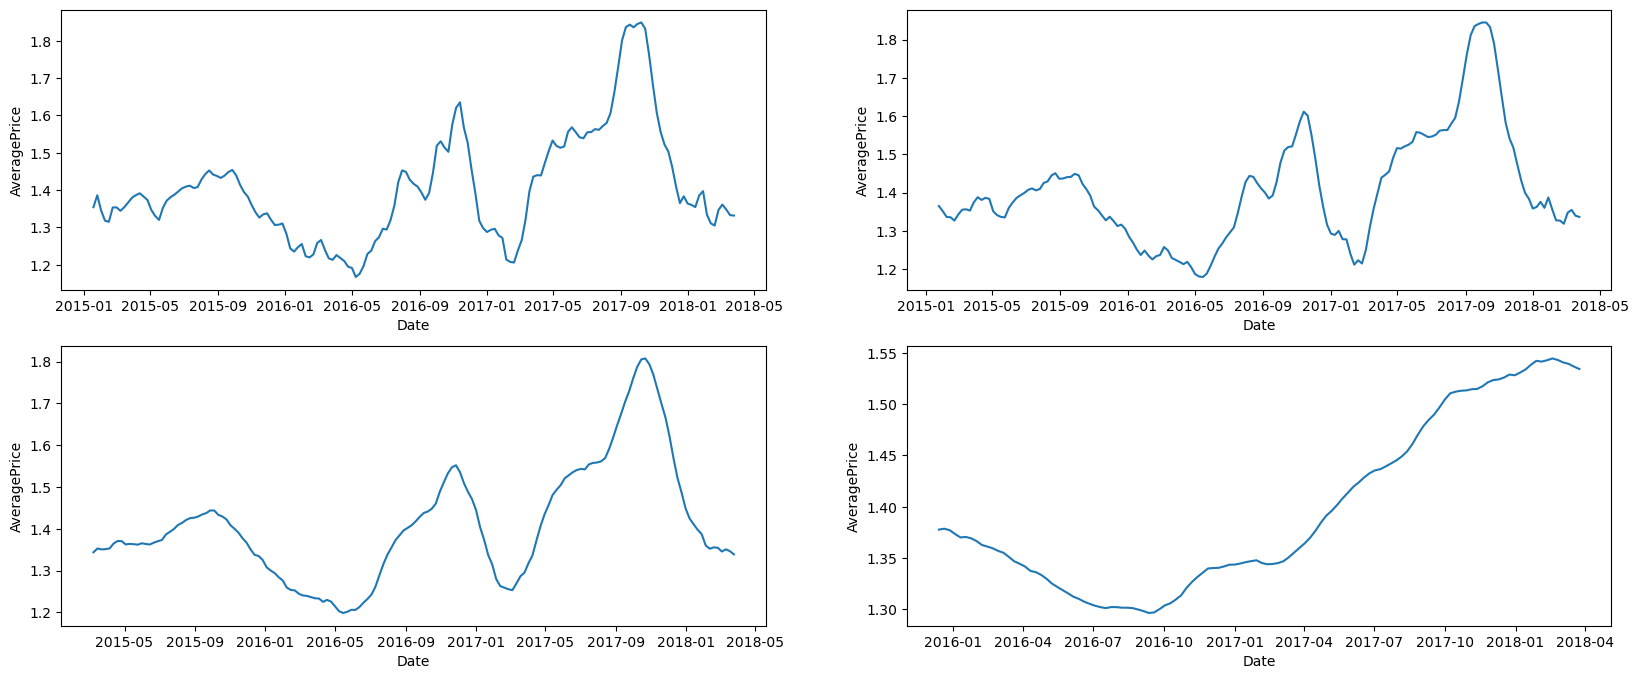

In [4]:
plt.figure(figsize=(20, 8))

plt.subplot(2, 2, 1)
sns.lineplot(data=avocado_mean['AveragePrice'].rolling(window=3).mean())
plt.subplot(2, 2, 2)
sns.lineplot(data=avocado_mean['AveragePrice'].rolling(window=4).mean())
plt.subplot(2, 2, 3)
sns.lineplot(data=avocado_mean['AveragePrice'].rolling(window=10).mean())
plt.subplot(2, 2, 4)
sns.lineplot(data=avocado_mean['AveragePrice'].rolling(window=50).mean())

plt.show()

In [5]:
avocado_ewm = avocado_mean['AveragePrice'].ewm(span=2).mean()

In [6]:
avocado_full_df = pd.read_csv("https://stepik.org/media/attachments/lesson/362453/avocado_full.csv", index_col=0)

In [7]:
avocado_full_df.head(3)

,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
Date,,,,,,,,,,,,
2015-01-04,1.75,27365.89,9307.34,3844.81,615.28,13598.46,13061.10,537.36,0.0,organic,2015,Southeast
2015-01-04,1.49,17723.17,1189.35,15628.27,0.00,905.55,905.55,0.00,0.0,organic,2015,Chicago
2015-01-04,1.68,2896.72,161.68,206.96,0.00,2528.08,2528.08,0.00,0.0,organic,2015,HarrisburgScranton


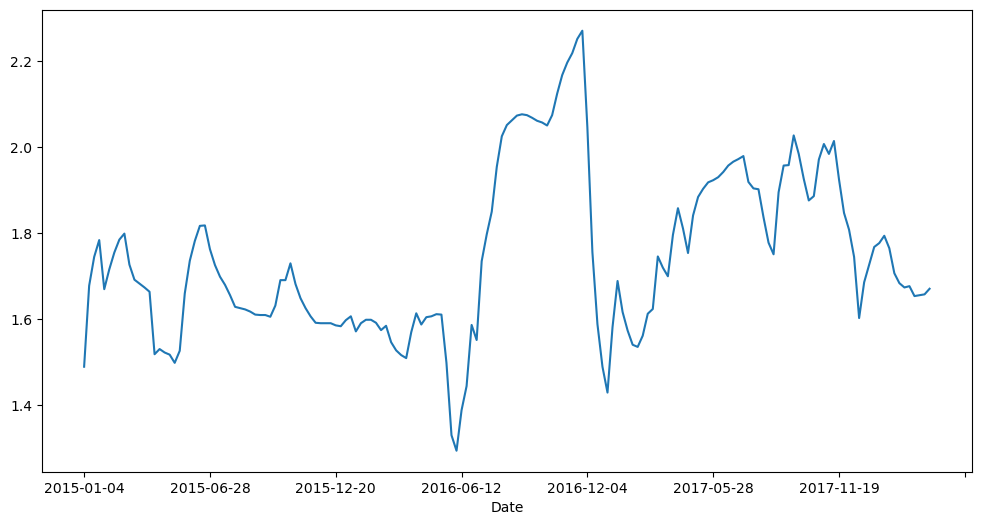

In [24]:
plt.figure(figsize=(12, 6))

avocado_full_df[
    (avocado_full_df['type'] == 'organic') &
    (avocado_full_df['region'] == 'Chicago')
]['AveragePrice'] \
    .ewm(span=4) \
    .mean() \
    .fillna(0) \
    .round(3) \
    .plot()

plt.show()

In [26]:
employees_delay_df = pd.read_csv("https://stepik.org/media/attachments/course/72204/delays.csv")

In [27]:
employees_delay_df.head()

,client_id,company_id,delay,revenue
0,2389,4240,-1 days -14:57:48.000000000,705436
1,7614,9544,-4 days -02:14:23.000000000,859266
2,2052,2427,-0 days -06:08:57.000000000,812416
3,9635,8054,-0 days -23:40:19.000000000,162312
4,8154,5503,-1 days -13:21:53.000000000,658844


In [29]:
employees_delay_df.dtypes

client_id     int64
company_id    int64
delay           str
revenue       int64
dtype: object

In [33]:
employees_delay_df.delay = employees_delay_df.delay.str.replace('-', '')

In [34]:
employees_delay_df['delay'] = pd.to_timedelta(employees_delay_df['delay'])

In [40]:
employees_delay_df['delay_categorical'] = pd.cut(x=employees_delay_df.delay, bins=3)

In [43]:
employees_delay_df['delay_categorical'] = pd.cut(x=employees_delay_df.delay, bins=4, labels=['less than 1 day',
                                                   '1-2 days',
                                                   '2-3 days',
                                                   'more than 3 days']
)

In [53]:
employees_delay_df.head()

,client_id,company_id,delay,revenue,delay_categorical
0,2389,4240,1 days 14:57:48,705436,1-2 days
1,7614,9544,4 days 02:14:23,859266,more than 3 days
2,2052,2427,0 days 06:08:57,812416,less than 1 day
3,9635,8054,0 days 23:40:19,162312,less than 1 day
4,8154,5503,1 days 13:21:53,658844,1-2 days


<Axes: xlabel='delay_categorical', ylabel='count'>

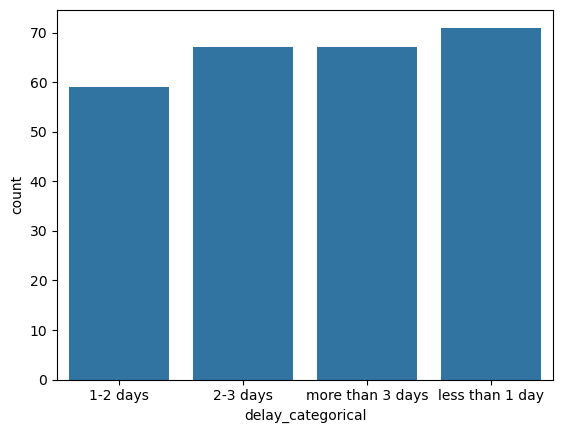

In [62]:
order = employees_delay_df.delay_categorical.value_counts(ascending=True).index
sns.countplot(data=employees_delay_df, x='delay_categorical', order=order)